In [8]:
# Import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read our CSV file into a pandas DataFrame
df = pd.read_csv('/content/insurance_processed.csv')

# Display the first 5 rows to check if it loaded correctly
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
# Get a concise summary of the dataframe
df.info()

# Check for any duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1000 non-null   int64  
 1   sex       1000 non-null   object 
 2   bmi       1000 non-null   float64
 3   children  1000 non-null   int64  
 4   smoker    1000 non-null   object 
 5   region    1000 non-null   object 
 6   charges   1000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB
Number of duplicate rows: 1


In [10]:
# Remove the duplicate row
df = df.drop_duplicates()

# Verify that it has been removed
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows after removal: 0


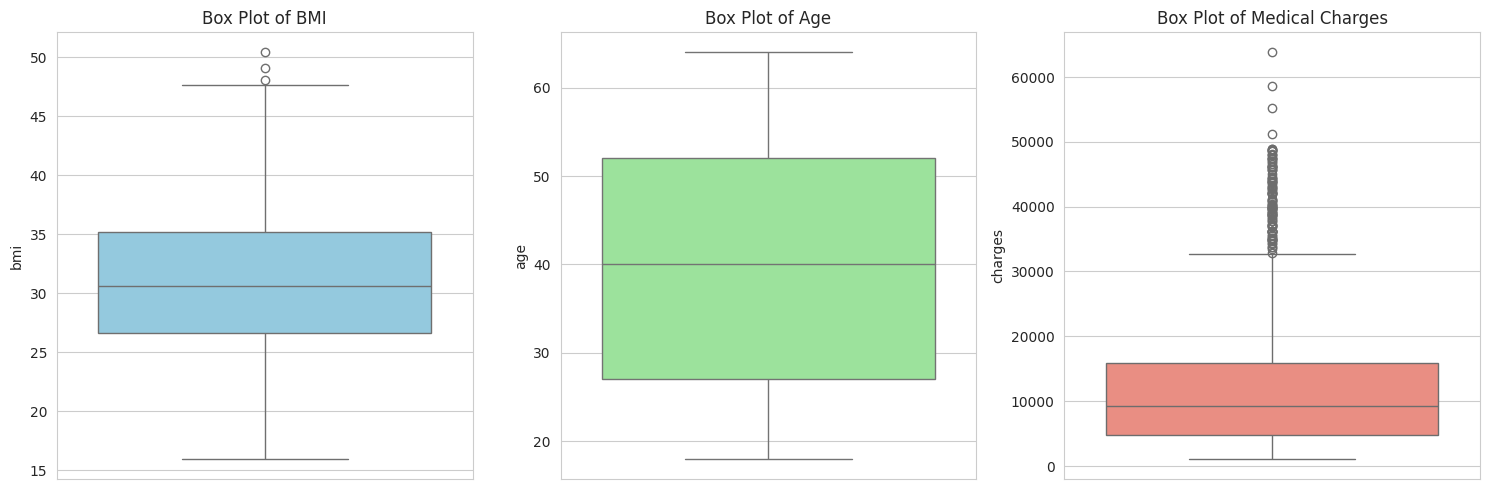

In [11]:
# Let's set up the canvas for our plots
plt.figure(figsize=(15, 5))

# Plot for BMI
plt.subplot(1, 3, 1) # (1 row, 3 columns, 1st plot)
sns.boxplot(y=df['bmi'], color='skyblue')
plt.title('Box Plot of BMI')

# Plot for Age
plt.subplot(1, 3, 2) # (1 row, 3 columns, 2nd plot)
sns.boxplot(y=df['age'], color='lightgreen')
plt.title('Box Plot of Age')

# Plot for Charges
plt.subplot(1, 3, 3) # (1 row, 3 columns, 3rd plot)
sns.boxplot(y=df['charges'], color='salmon')
plt.title('Box Plot of Medical Charges')

plt.tight_layout() # Adjusts plots to prevent them from overlapping
plt.show()

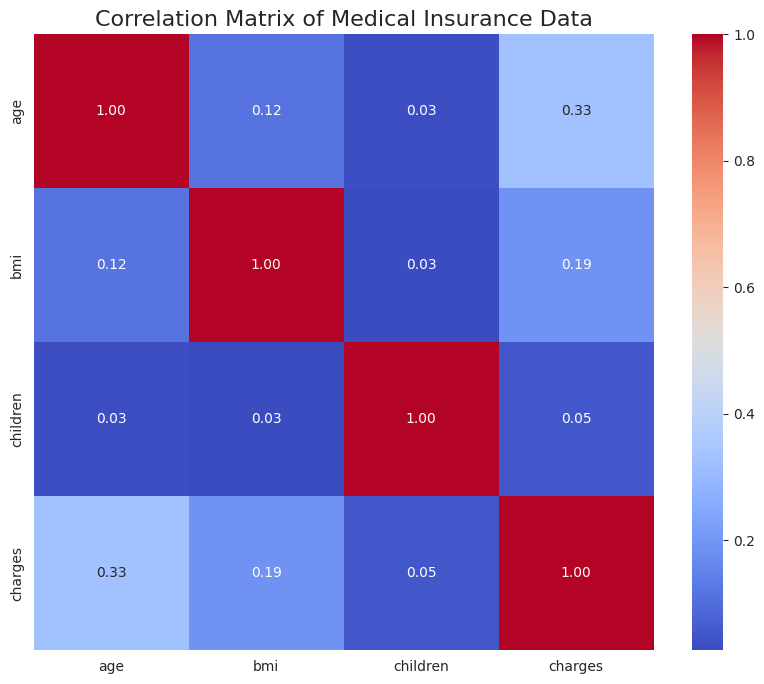

In [12]:
# Select only the numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Medical Insurance Data', fontsize=16)
plt.show()

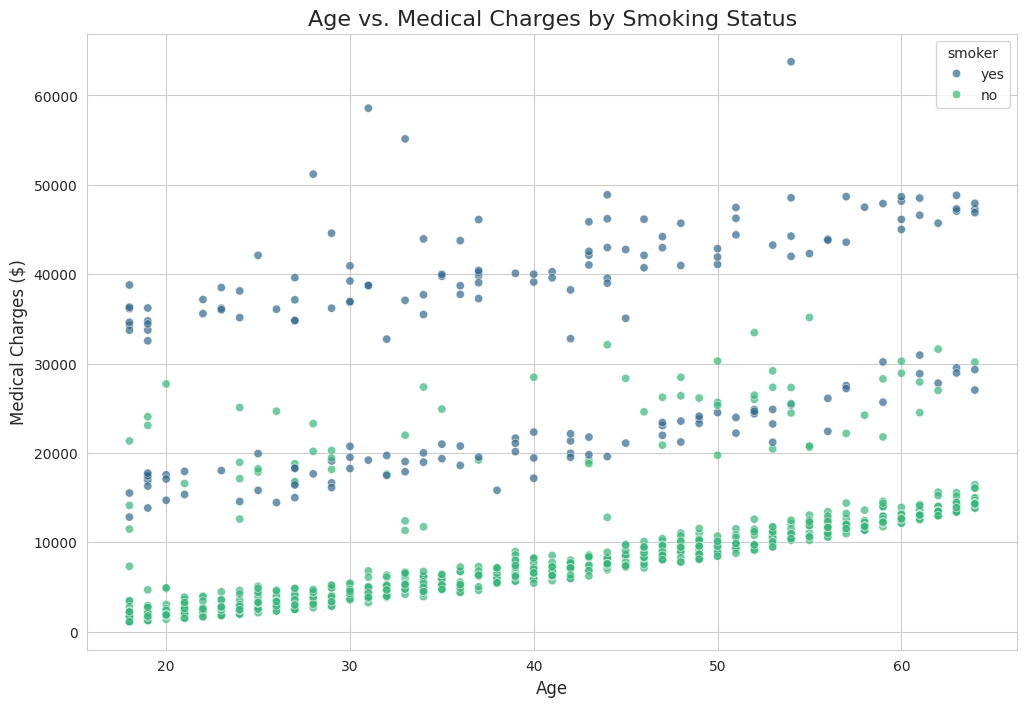

In [13]:
# Set the style for a nice-looking plot
sns.set_style("whitegrid")

# Create a scatter plot
plt.figure(figsize=(12, 8)) # Make the plot bigger
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='viridis', alpha=0.7)

# Add titles and labels for clarity
plt.title('Age vs. Medical Charges by Smoking Status', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Medical Charges ($)', fontsize=12)

# Show the plot
plt.show()

In [14]:
# Create a function to categorize BMI
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Apply this function to the 'bmi' column to create a new column
df['bmi_category'] = df['bmi'].apply(categorize_bmi)

# Display the first 5 rows to see our new column
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [16]:
# Save our enhanced DataFrame to a new CSV for the final step
df.to_csv('insurance_final_for_dashboard.csv', index=False)